In [1]:
# import jax.numpy as jnp
# import jax as j 
import matplotlib.pyplot as plt
import numpy as np


A = 1 
alpha = 0.1 
gamma = 0.5
epsilon = 0.01
iapp = 0.5 
v0 = 0.0
w0 = 0.0

tf = 5 #tempo final 
h = [0.01] #passos de tempo 


In [2]:
def f(v):
    return A* v *(alpha - v) * (v - 1)



def sistemaDeEquacoes(estado):
    v, w = estado
    dvdt = 1/epsilon * (f(v) - w + iapp)
    dwdt = v - gamma*w 
    return np.array([dvdt, dwdt])



def jacobiano(u,f):
    x,y = u
    dx = 1e-12
    
    j11 = (f([x+ dx, y])[0] - f([x,y])[0])/dx
    j12 = (f([x, y+dx])[0] - f([x,y])[0])/dx
    j21 = (f([x+ dx, y])[1] - f([x,y])[1])/dx
    j22 = (f([x, y+dx])[1] - f([x,y])[1])/dx
    
    return np.array([[j11,j12],
                     [j21,j22]])


def newton(f,x0,h,maxit=10, tol=1e-6):
    # S[n+1] = S[n] - J[n]*F[n]
    x = x0
    # J = j.jacfwd(f)
    
    for i in range(maxit):
        fx = f(x)
        # jx = J(x)
        J = jacobiano(x,f)
        delta = np.linalg.solve(J, -fx)
        x = x + delta
       
        if np.linalg.norm(delta) < tol:
            break
    
    return x
    


def eulerImplicito(sistema,h,y0,t):
    n = len(t)
    y = np.zeros((n, len(y0)))
    y[0] = y0
    
    for i in range(n-1):
        #  y - y_anterior - h * sistema(y) = 0 equacao que o newton resolve 
        def funcao(yk):
            return yk - y[i] - h * sistema(yk)
        
        # metodo de newton
        y[i+1] = newton(funcao, y[i],h)
    
    return y

    



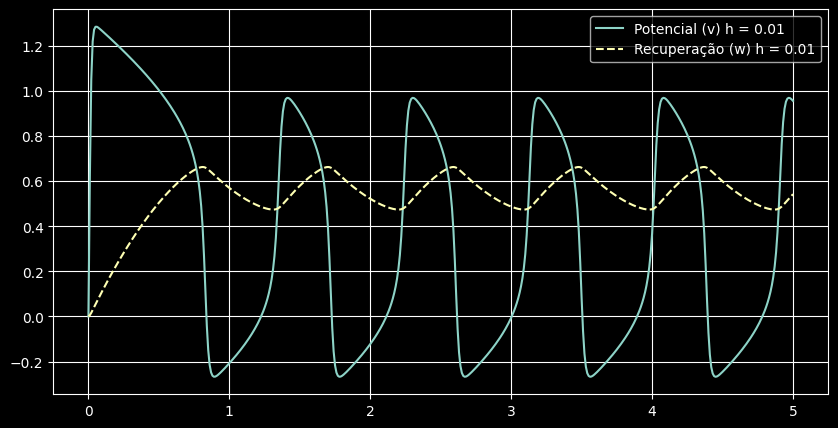

In [3]:
plt.figure(figsize=(10,5))
for i in h:
    t = np.arange(0, tf + i, i)
    
    solucao = eulerImplicito(sistemaDeEquacoes, i,[v0, w0], t)
    
    plt.plot(t, solucao[:,0], label='Potencial (v) h = {}'.format(i))
    plt.plot(t, solucao[:,1], label='Recuperação (w) h = {}'.format(i), linestyle='--')


plt.legend()
plt.grid(True)
plt.show()

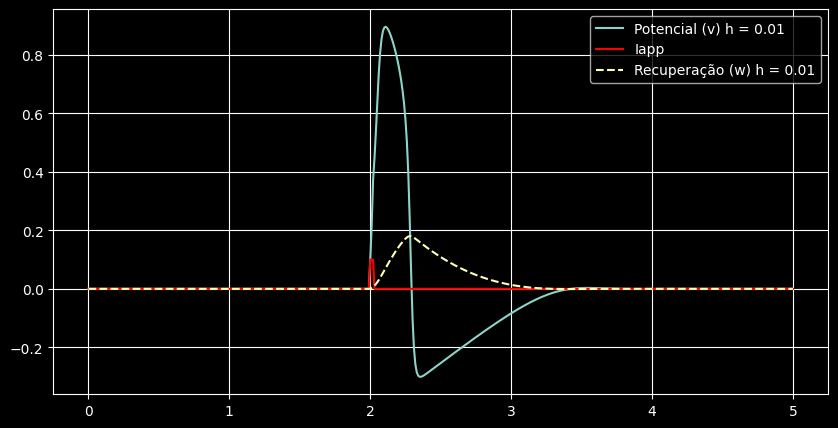

In [4]:
def sistemaDeEquacoes2(estado, corrente_atual):
    v, w = estado
    dvdt = 1/epsilon * (f(v) - w + corrente_atual)
    dwdt = v - gamma*w 
    return np.array([dvdt, dwdt])


def eulerImplicito_com_pulso(sistema, h, y0, t, iapp_vet):
    n = len(t)
    y = np.zeros((n, len(y0)))
    y[0] = y0
    
    for i in range(n-1):
        # Pega a corrente exata do próximo passo de tempo
        corrente_no_instante = iapp_vet[i+1]
        
        def funcao_residuo(yk):
            return yk - y[i] - h * sistema(yk, corrente_no_instante)
        
        y[i+1] = newton(funcao_residuo, y[i], h)
    
    return y



plt.figure(figsize=(10,5))
for i in h:
    t = np.arange(0, tf + i, i)
    iapp_vet = np.zeros(len(t))

    iapp_vet[(t >= 2.0) & (t <= 2.02)] = 0.1    
    
    solucao = eulerImplicito_com_pulso(sistemaDeEquacoes2, i, [v0, w0], t, iapp_vet)
    
    plt.plot(t, solucao[:,0], label='Potencial (v) h = {}'.format(i))
    plt.plot(t,iapp_vet, label='Iapp', color='red')  # Plot da corrente de pulso
    plt.plot(t, solucao[:,1], label='Recuperação (w) h = {}'.format(i), linestyle='--', )
plt.legend()
plt.grid(True)
plt.show()